In [1]:
"""
Solution pour la Data Battle 2026 - Prédiction de la fin des orages
Version adaptée au format réel des données (avec airport_alert_id pour les CG)
"""

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, precision_recall_curve, classification_report
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')


In [2]:

# =============================================================================
# 1. CHARGEMENT DES DONNÉES
# =============================================================================

def load_data(filepath):
    """
    Charge le fichier CSV contenant les éclairs.
    Le fichier doit contenir les colonnes décrites.
    """
    df = pd.read_csv(filepath, parse_dates=['date'])
    # Tri par date pour garantir l'ordre chronologique
    df = df.sort_values('date').reset_index(drop=True)
    return df

# =============================================================================
# 2. CONSTRUCTION DES ALERTES À PARTIR DES ÉCLAIRS NUAGE-SOL
# =============================================================================

def build_alerts_from_cg(df, radius_km=30, end_delay_min=30):
    """
    Crée une table des alertes à partir des éclairs nuage-sol (icloud=False)
    qui ont un airport_alert_id non nul.
    Pour chaque alerte (aéroport + airport_alert_id), on calcule :
        - start_time : date du premier éclair nuage-sol de l'alerte
        - end_time : date du dernier éclair nuage-sol (is_last_lightning_cloud_ground=True)
        - alert_end_official : end_time + end_delay_min
        - lightning_count : nombre total d'éclairs (tous types) dans l'alerte
    """
    # Filtrer les éclairs nuage-sol avec un ID d'alerte
    cg_strikes = df[(df['icloud'] == False) & (df['airport_alert_id'].notna())].copy()
    # Convertir airport_alert_id en entier (car il peut être float dans le CSV)
    cg_strikes['airport_alert_id'] = cg_strikes['airport_alert_id'].astype(int)
    
    alerts = []
    for (airport, alert_id), group in cg_strikes.groupby(['airport', 'airport_alert_id']):
        # Trier par date
        group = group.sort_values('date')
        start_time = group['date'].iloc[0]
        # Le dernier éclair est celui où is_last_lightning_cloud_ground est True
        last_cg = group[group['is_last_lightning_cloud_ground'] == True]
        if len(last_cg) == 0:
            # Si le flag est absent (peut arriver), on prend le dernier de la série
            end_time = group['date'].iloc[-1]
        else:
            end_time = last_cg['date'].iloc[0]
        
        # Récupérer tous les éclairs (tous types) dans un intervalle élargi autour de l'alerte
        # On prend [start_time - 5min, end_time + 5min] pour capturer les précurseurs/traînards
        buffer = pd.Timedelta(minutes=5)
        mask = (df['airport'] == airport) & (df['date'] >= start_time - buffer) & (df['date'] <= end_time + buffer)
        all_in_alert = df[mask]
        
        alert_info = {
            'airport': airport,
            'airport_alert_id': alert_id,
            'start_time': start_time,
            'end_time': end_time,
            'alert_end_official': end_time + pd.Timedelta(minutes=end_delay_min),
            'lightning_count': len(all_in_alert),
            'cg_count': len(group)
        }
        alerts.append(alert_info)
    
    alerts_df = pd.DataFrame(alerts)
    return alerts_df

# =============================================================================
# 3. GÉNÉRATION DES ÉCHANTILLONS POUR UNE ALERTE
# =============================================================================

def get_strikes_for_alert(df, airport, start_time, end_time, buffer_min=5):
    """
    Récupère tous les éclairs (tous types) pour un aéroport donné entre start_time - buffer et end_time + buffer.
    """
    start = start_time - pd.Timedelta(minutes=buffer_min)
    end = end_time + pd.Timedelta(minutes=buffer_min)
    mask = (df['airport'] == airport) & (df['date'] >= start) & (df['date'] <= end)
    return df[mask].copy().sort_values('date')

def generate_samples_for_alert(alert_df, df_full, horizon_min=30, freq_min=1, buffer_min=5):
    """
    Pour une alerte donnée (ligne de alerts_df), génère les échantillons.
    alert_df : ligne de la table alerts (contenant airport, start_time, end_time, alert_end_official)
    df_full : DataFrame complet des éclairs
    """
    airport = alert_df['airport']
    start = alert_df['start_time']
    end_cg = alert_df['end_time']
    end_official = alert_df['alert_end_official']
    
    # Récupérer tous les éclairs de l'épisode (avec buffer)
    strikes = get_strikes_for_alert(df_full, airport, start, end_cg, buffer_min)
    
    # Grille temporelle : de start (ou start - buffer?) à end_official
    times = pd.date_range(start, end_official, freq=f'{freq_min}min')
    
    samples = []
    for t in times:
        # Éclairs passés (avant t)
        past = strikes[strikes['date'] < t]
        
        # Cible : y a-t-il un éclair (quelconque) dans [t, t+horizon_min] ?
        future = strikes[(strikes['date'] >= t) & (strikes['date'] < t + pd.Timedelta(minutes=horizon_min))]
        y = 1 if len(future) > 0 else 0
        
        # Calcul des features
        features = compute_features(past, t, airport)
        features['time'] = t
        features['y'] = y
        # On garde l'identifiant de l'alerte pour le suivi
        features['airport_alert_id'] = alert_df['airport_alert_id']
        samples.append(features)
    
    return pd.DataFrame(samples)

def compute_features(past_strikes, current_time, airport):
    """
    Calcule les features à partir des éclairs passés (DataFrame) et du contexte.
    """
    feat = {'airport': airport}
    
    if len(past_strikes) == 0:
        # Pas d'éclair avant t
        feat['time_since_last'] = np.nan
        feat['time_since_last_cg'] = np.nan
        feat['time_since_last_ic'] = np.nan
        feat['time_since_first'] = 0
        feat['strike_count_5min'] = 0
        feat['strike_count_10min'] = 0
        feat['strike_count_30min'] = 0
        feat['rate_5min'] = 0
        feat['rate_10min'] = 0
        feat['rate_30min'] = 0
        feat['std_interarrival'] = np.nan
        feat['mean_dist'] = np.nan
        feat['trend_dist'] = np.nan
        feat['angular_spread'] = np.nan
        feat['prop_ic'] = np.nan
        feat['mean_amplitude'] = np.nan
    else:
        last = past_strikes.iloc[-1]
        feat['time_since_last'] = (current_time - last['date']).total_seconds() / 60.0
        
        last_cg = past_strikes[past_strikes['icloud'] == False]
        if len(last_cg) > 0:
            feat['time_since_last_cg'] = (current_time - last_cg.iloc[-1]['date']).total_seconds() / 60.0
        else:
            feat['time_since_last_cg'] = np.nan
        
        last_ic = past_strikes[past_strikes['icloud'] == True]
        if len(last_ic) > 0:
            feat['time_since_last_ic'] = (current_time - last_ic.iloc[-1]['date']).total_seconds() / 60.0
        else:
            feat['time_since_last_ic'] = np.nan
        
        feat['time_since_first'] = (current_time - past_strikes.iloc[0]['date']).total_seconds() / 60.0
        
        for window in [5, 10, 30]:
            mask = past_strikes['date'] >= current_time - pd.Timedelta(minutes=window)
            cnt = mask.sum()
            feat[f'strike_count_{window}min'] = cnt
            feat[f'rate_{window}min'] = cnt / window if window>0 else 0
        
        if len(past_strikes) >= 2:
            intervals = past_strikes['date'].diff().dt.total_seconds().dropna() / 60.0
            feat['std_interarrival'] = intervals.std()
        else:
            feat['std_interarrival'] = np.nan
        
        # Spatiales
        feat['mean_dist'] = past_strikes['dist'].mean()
        recent = past_strikes.tail(min(5, len(past_strikes)))
        if len(recent) >= 2:
            x = np.arange(len(recent))
            y = recent['dist'].values
            slope = np.polyfit(x, y, 1)[0]
            feat['trend_dist'] = slope
        else:
            feat['trend_dist'] = 0
        
        feat['angular_spread'] = past_strikes['azimuth'].std()
        
        # Physiques
        feat['prop_ic'] = past_strikes['icloud'].mean()
        feat['mean_amplitude'] = past_strikes['amplitude'].mean()
    
    # Contexte temporel cyclique
    feat['month'] = current_time.month
    feat['hour'] = current_time.hour
    feat['month_sin'] = np.sin(2 * np.pi * current_time.month / 12)
    feat['month_cos'] = np.cos(2 * np.pi * current_time.month / 12)
    feat['hour_sin'] = np.sin(2 * np.pi * current_time.hour / 24)
    feat['hour_cos'] = np.cos(2 * np.pi * current_time.hour / 24)
    
    return feat

def prepare_dataset(df, alerts_df, horizon_min=30, freq_min=1, buffer_min=5):
    """
    Parcourt toutes les alertes et construit le dataset d'entraînement.
    """
    all_samples = []
    for idx, alert_row in alerts_df.iterrows():
        samples = generate_samples_for_alert(alert_row, df, horizon_min, freq_min, buffer_min)
        all_samples.append(samples)
        if (idx+1) % 10 == 0:
            print(f"Alertes traitées : {idx+1}/{len(alerts_df)}")
    full_df = pd.concat(all_samples, ignore_index=True)
    return full_df


In [ ]:
# =============================================================================
# 4. ENTRAÎNEMENT DU MODÈLE
# =============================================================================

def train_model(X_train, y_train, X_val, y_val):
    """
    Entraîne un modèle XGBoost avec early stopping en utilisant l'API native.
    """
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    
    params = {
        'objective': 'binary:logistic',
        'max_depth': 6,
        'learning_rate': 0.05,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'eval_metric': 'logloss',
        'seed': 42
    }
    
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        evals=[(dval, 'validation')],
        early_stopping_rounds=50,
        verbose_eval=100
    )
    return model

In [4]:

# =============================================================================
# 5. EXEMPLE D'EXÉCUTION
# =============================================================================


# 1. Charger les données
print("Chargement des données...")
# Remplacez par le chemin réel de votre fichier
df = load_data('../data_train_databattle2026/segment_alerts_all_airports_train.csv')

# 2. Construire les alertes
print("Construction des alertes à partir des éclairs nuage-sol...")
alerts = build_alerts_from_cg(df)
print(f"Nombre d'alertes trouvées : {len(alerts)}")

# 3. Générer le dataset d'apprentissage
print("Génération des échantillons temporels...")
# Attention : cela peut être long. Pour tester, on peut limiter à quelques alertes.
# dataset = prepare_dataset(df, alerts.head(50), horizon_min=30, freq_min=5)  # test avec 50 alertes
dataset = prepare_dataset(df, alerts, horizon_min=30, freq_min=1)  # complet, peut être très long

# 4. Préparer les features et la cible
feature_cols = [col for col in dataset.columns if col not in ['time', 'y', 'airport', 'airport_alert_id']]
# Encoder l'aéroport
le = LabelEncoder()
dataset['airport_encoded'] = le.fit_transform(dataset['airport'])
feature_cols.append('airport_encoded')

X = dataset[feature_cols].copy()
y = dataset['y']

# Remplacer les NaN (par exemple par -1 pour les temps sans éclair)
X = X.fillna(-1)

# 5. Séparation temporelle : on utilise la chronologie des alertes
# On récupère les dates de début d'alerte uniques pour chaque échantillon
# (on peut le faire via un merge avec alerts)
alert_dates = alerts[['airport', 'airport_alert_id', 'start_time']].copy()
dataset_with_date = dataset.merge(alert_dates, on=['airport', 'airport_alert_id'])
dataset_with_date = dataset_with_date.sort_values('start_time')

# 80% des alertes les plus anciennes pour l'entraînement
n_train = int(0.8 * len(alerts))
# Récupérer les alertes triées
alerts_sorted = alerts.sort_values('start_time').reset_index(drop=True)
train_alert_ids = alerts_sorted.iloc[:n_train][['airport', 'airport_alert_id']]
val_alert_ids = alerts_sorted.iloc[n_train:][['airport', 'airport_alert_id']]

# Créer un index booléen pour les échantillons
train_idx = dataset_with_date[['airport', 'airport_alert_id']].apply(tuple, axis=1).isin(train_alert_ids.apply(tuple, axis=1))
val_idx = dataset_with_date[['airport', 'airport_alert_id']].apply(tuple, axis=1).isin(val_alert_ids.apply(tuple, axis=1))

X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y[train_idx], y[val_idx]

print(f"Taille entraînement : {len(X_train)}, validation : {len(X_val)}")



Chargement des données...
Construction des alertes à partir des éclairs nuage-sol...
Nombre d'alertes trouvées : 2627
Génération des échantillons temporels...
Alertes traitées : 10/2627
Alertes traitées : 20/2627
Alertes traitées : 30/2627
Alertes traitées : 40/2627
Alertes traitées : 50/2627
Alertes traitées : 60/2627
Alertes traitées : 70/2627
Alertes traitées : 80/2627
Alertes traitées : 90/2627
Alertes traitées : 100/2627
Alertes traitées : 110/2627
Alertes traitées : 120/2627
Alertes traitées : 130/2627
Alertes traitées : 140/2627
Alertes traitées : 150/2627
Alertes traitées : 160/2627
Alertes traitées : 170/2627
Alertes traitées : 180/2627
Alertes traitées : 190/2627
Alertes traitées : 200/2627
Alertes traitées : 210/2627
Alertes traitées : 220/2627
Alertes traitées : 230/2627
Alertes traitées : 240/2627
Alertes traitées : 250/2627
Alertes traitées : 260/2627
Alertes traitées : 270/2627
Alertes traitées : 280/2627
Alertes traitées : 290/2627
Alertes traitées : 300/2627
Alertes tr

In [ ]:
import joblib
# 6. Entraînement
print("Entraînement du modèle...")
model = train_model(X_train, y_train, X_val, y_val)  # model est un Booster

In [ ]:
# 7. Évaluation
# Convertir X_val en DMatrix
dval = xgb.DMatrix(X_val)
y_pred_proba = model.predict(dval)  # probabilités pour la classe 1
y_pred = (y_pred_proba >= 0.5).astype(int)

print("ROC AUC:", roc_auc_score(y_val, y_pred_proba))
print(classification_report(y_val, y_pred))

# 8. Sauvegarde
model.save_model('modele_fin_orage.json')
joblib.dump(le, 'label_encoder_airport.pkl')

Entraînement du modèle...
[0]	validation-logloss:0.65471
[100]	validation-logloss:0.24597
[167]	validation-logloss:0.24748
ROC AUC: 0.9623253722018917
              precision    recall  f1-score   support

           0       0.88      0.90      0.89     14727
           1       0.91      0.90      0.91     18310

    accuracy                           0.90     33037
   macro avg       0.90      0.90      0.90     33037
weighted avg       0.90      0.90      0.90     33037



['label_encoder_airport.pkl']

Top 10 features par gain :
               feature         gain
0      time_since_last  1100.997803
7            rate_5min   853.242920
4    strike_count_5min   447.898224
1   time_since_last_cg    59.811188
5   strike_count_10min    49.564381
2   time_since_last_ic    27.614288
10    std_interarrival    26.999096
12          trend_dist    21.859192
13      angular_spread    21.722940
19           month_cos    21.578892


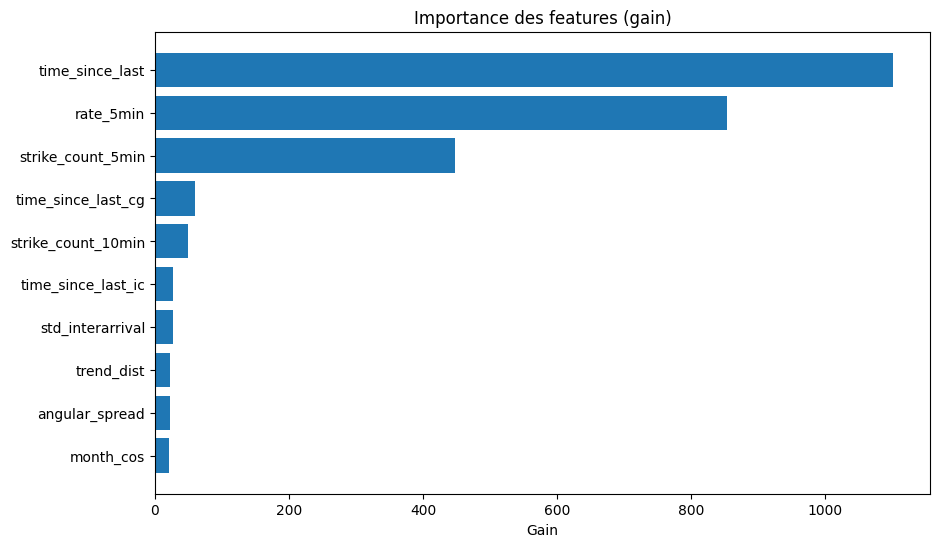

In [6]:
# Importance basée sur le nombre de fois qu'une feature est utilisée pour spliter
importance_weight = model.get_score(importance_type='weight')
# Importance basée sur le gain moyen (réduction de la perte) apporté par la feature
importance_gain = model.get_score(importance_type='gain')

# Convertir en DataFrame pour affichage
import pandas as pd
df_imp = pd.DataFrame({
    'feature': list(importance_gain.keys()),
    'gain': list(importance_gain.values())
}).sort_values('gain', ascending=False)

print("Top 10 features par gain :")
print(df_imp.head(10))

# Graphique
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.barh(df_imp['feature'][:10], df_imp['gain'][:10])
plt.xlabel('Gain')
plt.title('Importance des features (gain)')
plt.gca().invert_yaxis()
plt.show()

In [7]:
# =============================================================================
# Calcul du gain temporel opérationnel (version corrigée)
# =============================================================================

# 1. Ajouter à la table alerts la date du dernier éclair réel (tous types)
def get_last_strike_for_alert(alert_row, df_full, buffer_min=5):
    strikes = get_strikes_for_alert(df_full, 
                                     alert_row['airport'], 
                                     alert_row['start_time'], 
                                     alert_row['end_time'], 
                                     buffer_min)
    return strikes['date'].max()

alerts['last_strike_real'] = alerts.apply(lambda row: get_last_strike_for_alert(row, df), axis=1)

# 2. Préparer le DataFrame de validation avec les prédictions
val_data = dataset.loc[val_idx].copy()
val_data['proba'] = y_pred_proba

# 3. Fusionner avec alerts pour avoir last_strike_real
val_data = val_data.merge(alerts[['airport', 'airport_alert_id', 'last_strike_real']],
                          on=['airport', 'airport_alert_id'], how='left')

# 4. Seuil de probabilité (à ajuster selon la courbe PR)
seuil = 0.3

# 5. Grouper par alerte et calculer le gain
gains = []
erreurs = 0
total_alertes = 0

for alert_id, group in val_data.groupby('airport_alert_id'):
    total_alertes += 1
    group = group.sort_values('time')
    last_strike = group['last_strike_real'].iloc[0]
    
    # Instants après le dernier éclair réel
    after = group[group['time'] > last_strike]
    if len(after) == 0:
        continue  # pas d'instant après le dernier éclair (cas théorique)
    
    # Premier instant où la probabilité passe sous le seuil
    low_risk = after[after['proba'] < seuil]
    if len(low_risk) > 0:
        lift_time = low_risk.iloc[0]['time']
        # Vérifier si un éclair réel survient après lift_time (le dernier éclair est après lift_time ?)
        if last_strike > lift_time:
            erreurs += 1  # levée trop tôt
        else:
            gain = (lift_time - last_strike).total_seconds() / 60.0
            gains.append(gain)
    # sinon pas de levée anticipée (gain nul)

# 6. Résultats
print(f"Nombre total d'alertes analysées : {total_alertes}")
print(f"Alertes avec levée anticipée : {len(gains)}")
if len(gains) > 0:
    print(f"Gain moyen (parmi les alertes levées plus tôt) : {np.mean(gains):.1f} minutes")
print(f"Taux d'erreur (levées trop tôt) : {erreurs / total_alertes:.2%}")

Nombre total d'alertes analysées : 339
Alertes avec levée anticipée : 339
Gain moyen (parmi les alertes levées plus tôt) : 5.6 minutes
Taux d'erreur (levées trop tôt) : 0.00%


Analyse pour seuil = 0.05...
Analyse pour seuil = 0.10...
Analyse pour seuil = 0.15...
Analyse pour seuil = 0.20...
Analyse pour seuil = 0.25...
Analyse pour seuil = 0.30...
Analyse pour seuil = 0.35...
Analyse pour seuil = 0.40...
Analyse pour seuil = 0.45...
Analyse pour seuil = 0.50...
Analyse pour seuil = 0.55...
Analyse pour seuil = 0.60...
Analyse pour seuil = 0.65...
Analyse pour seuil = 0.70...
Analyse pour seuil = 0.75...
Analyse pour seuil = 0.80...
    seuil  gain_moyen  taux_erreur  nb_alertes_anticipees
0    0.05   14.907129          0.0                    339
1    0.10   10.936627          0.0                    339
2    0.15    8.744887          0.0                    339
3    0.20    7.314208          0.0                    339
4    0.25    6.308309          0.0                    339
5    0.30    5.550197          0.0                    339
6    0.35    4.933677          0.0                    339
7    0.40    4.441052          0.0                    339
8    0.45    3

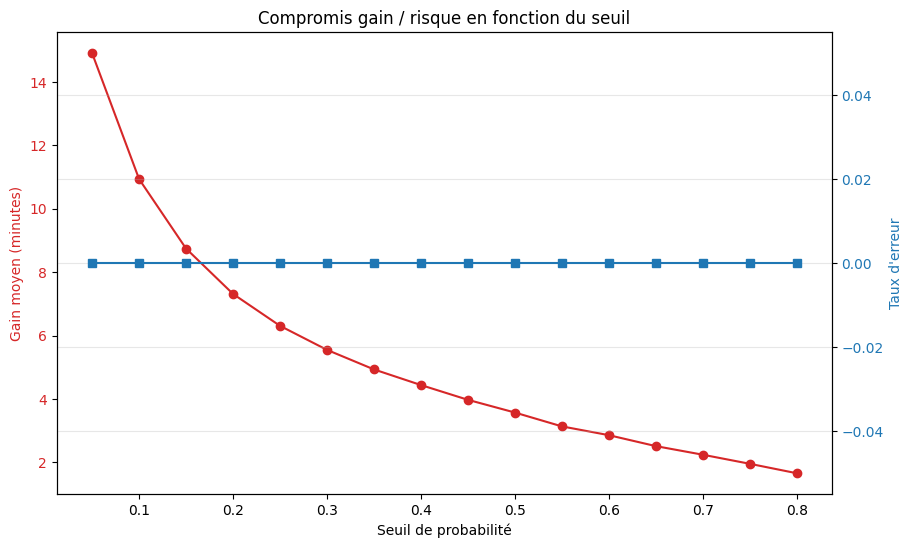

In [8]:
# =============================================================================
# Analyse du compromis gain / risque en fonction du seuil
# =============================================================================

# Seuils à tester (par exemple de 0.05 à 0.8 par pas de 0.05)
seuils = np.arange(0.05, 0.81, 0.05)

resultats = []

for seuil in seuils:
    print(f"Analyse pour seuil = {seuil:.2f}...")
    gains = []
    erreurs = 0
    total_alertes = 0
    
    for alert_id, group in val_data.groupby('airport_alert_id'):
        total_alertes += 1
        group = group.sort_values('time')
        last_strike = group['last_strike_real'].iloc[0]
        after = group[group['time'] > last_strike]
        if len(after) == 0:
            continue
        low_risk = after[after['proba'] < seuil]
        if len(low_risk) > 0:
            lift_time = low_risk.iloc[0]['time']
            if last_strike > lift_time:
                erreurs += 1
            else:
                gain = (lift_time - last_strike).total_seconds() / 60.0
                gains.append(gain)
    
    gain_moyen = np.mean(gains) if gains else 0
    taux_erreur = erreurs / total_alertes if total_alertes > 0 else 0
    resultats.append({
        'seuil': seuil,
        'gain_moyen': gain_moyen,
        'taux_erreur': taux_erreur,
        'nb_alertes_anticipees': len(gains)
    })

# Convertir en DataFrame
df_resultats = pd.DataFrame(resultats)

# Affichage
print(df_resultats)

# Tracé
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10,6))

color = 'tab:red'
ax1.set_xlabel('Seuil de probabilité')
ax1.set_ylabel('Gain moyen (minutes)', color=color)
ax1.plot(df_resultats['seuil'], df_resultats['gain_moyen'], color=color, marker='o')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel("Taux d'erreur", color=color)
ax2.plot(df_resultats['seuil'], df_resultats['taux_erreur'], color=color, marker='s')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Compromis gain / risque en fonction du seuil")
plt.grid(True, alpha=0.3)
plt.show()